In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

data6 = data.loc[:, ['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]
data6['gender'] = data6['gender'].replace({1: 'Male', 2: 'Female'})
data6['drinking'] = data6['drinking'].replace({0: 'Non-drinking', 1: 'Drinking'})
data6['smoking'] = data6['smoking'].replace({1: 'Non-smoking', 2: 'Non-smoking', 3: 'Smoking'})

male_data = data6.loc[data6.gender=='Male', ['gender','weight','waist','drinking','smoking']]
female_data = data6.loc[data6.gender=='Female', ['gender','weight','waist','drinking','smoking']]

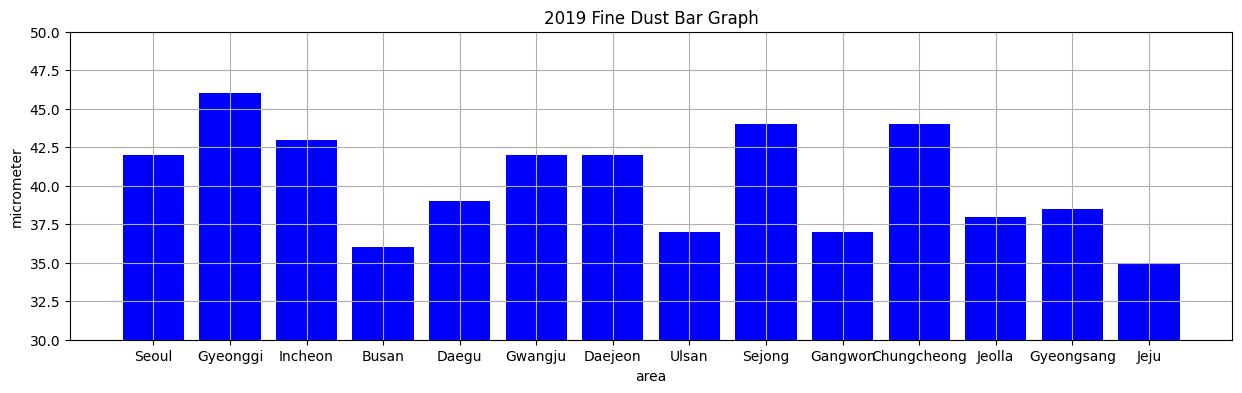

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('fine_dust.xlsx', index_col='area')
data2019 = data[2019]

plt.figure(figsize=(15,4))
plt.bar(data2019.index, data2019, color='b')
plt.ylim(30, 50)
plt.xlabel('area')
plt.ylabel('micrometer')
plt.title('2019 Fine Dust Bar Graph')
plt.grid()
plt.show()

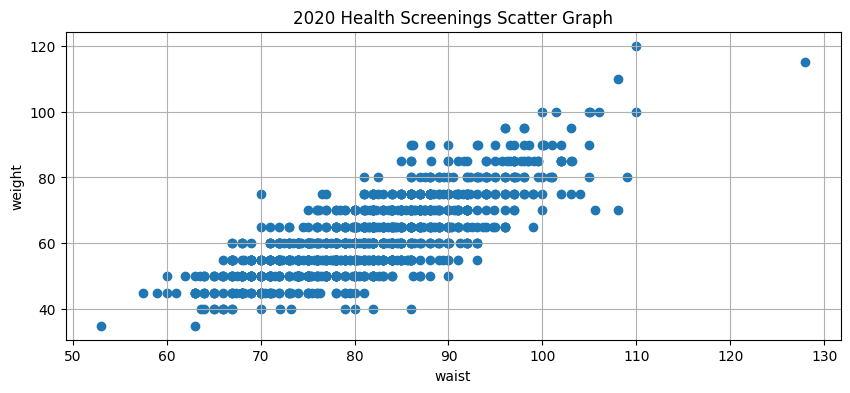

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
waistdata = data['waist']
weightdata = data['weight']

plt.figure(figsize=(10,4))
plt.scatter(waistdata, weightdata)
plt.xlabel('waist')
plt.ylabel('weight')
plt.title('2020 Health Screenings Scatter Graph')
plt.grid()
plt.show()

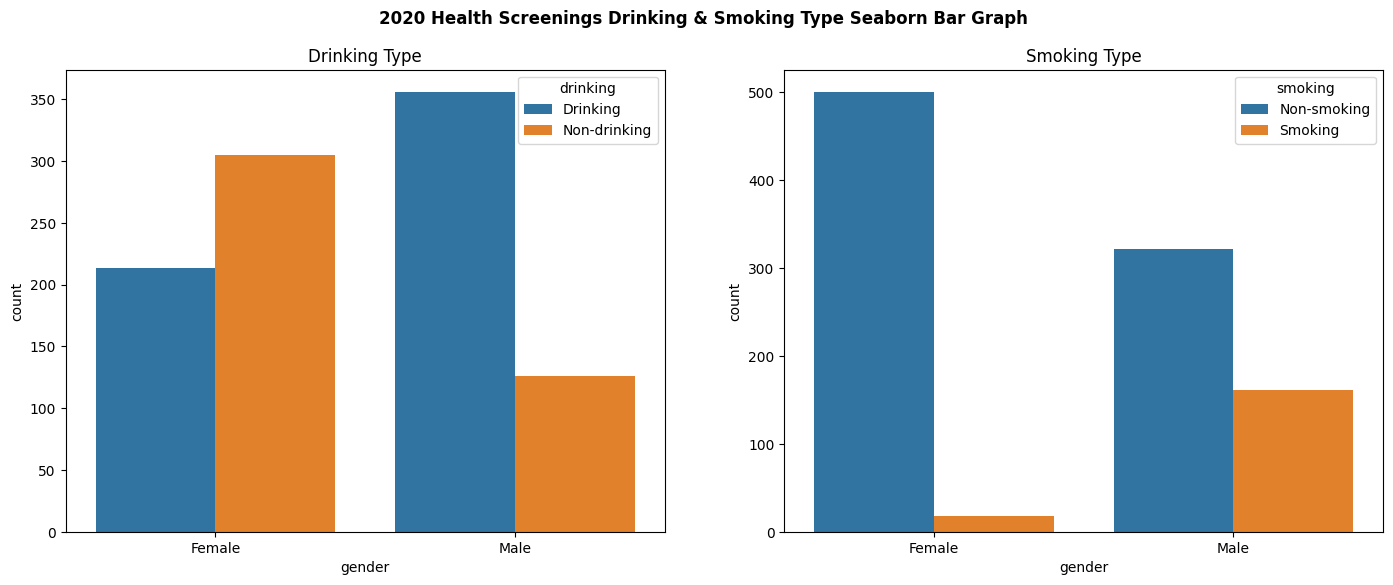

In [11]:
drinking = data6.groupby(['gender', 'drinking']).size().reset_index(name='count')
smoking = data6.groupby(['gender', 'smoking']).size().reset_index(name='count')

fig = plt.figure(figsize=(17,6))

area1 = fig.add_subplot(1,2,1)
area2 = fig.add_subplot(1,2,2)

ax1 = sns.barplot(data=drinking, x='gender', y='count', hue='drinking', ax=area1)
ax2 = sns.barplot(data=smoking, x='gender', y='count', hue='smoking', ax=area2)

fig.suptitle('2020 Health Screenings Drinking & Smoking Type Seaborn Bar Graph', fontweight='bold')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')

plt.show()

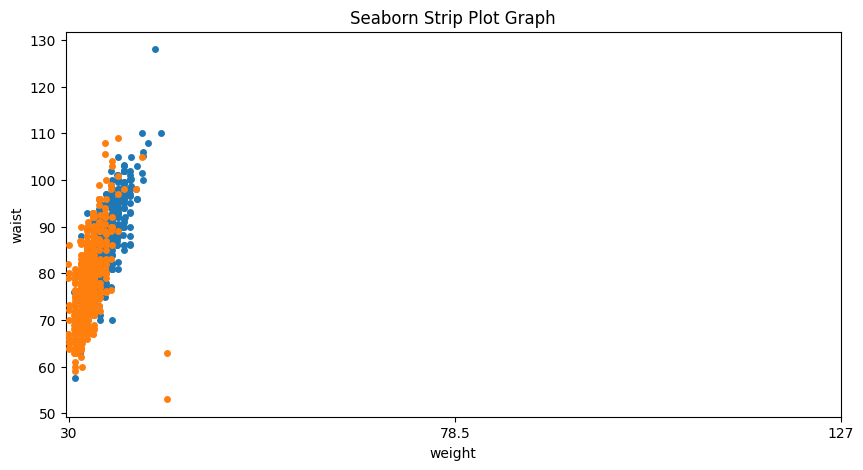

In [12]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.stripplot(data=male_data, x='weight', y='waist')
sns.stripplot(data=female_data, x='weight', y='waist')

plt.xticks(np.arange(0,127,63), labels=[30, 78.5, 127])
plt.show()


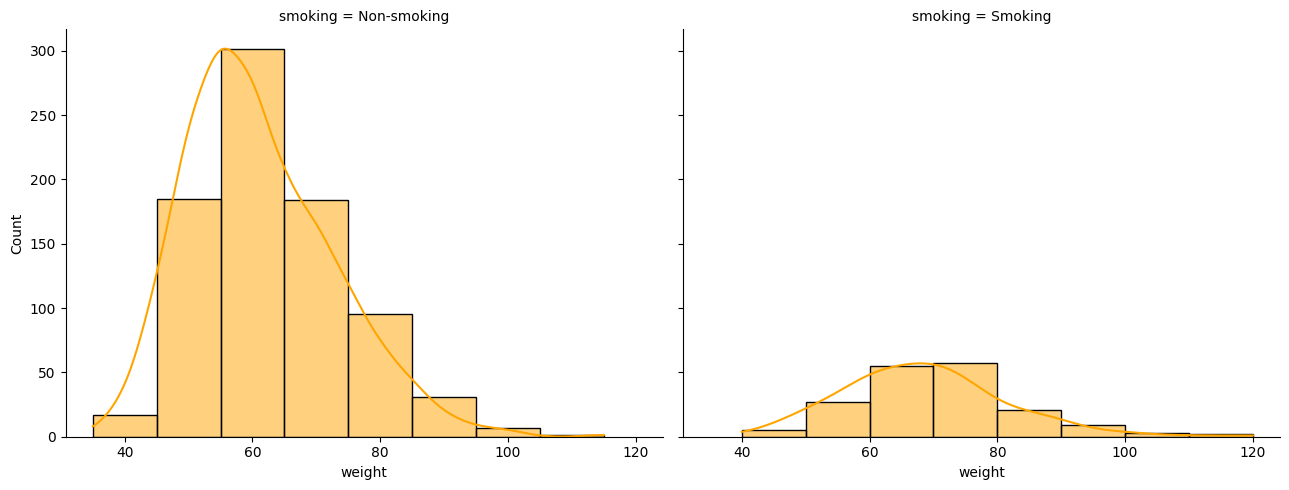

In [16]:
fg = sns.FacetGrid(data6, col='smoking', height=5, aspect=1.3)
fg.map(sns.histplot, 'weight', bins=8, color='orange', kde=True)

plt.show()

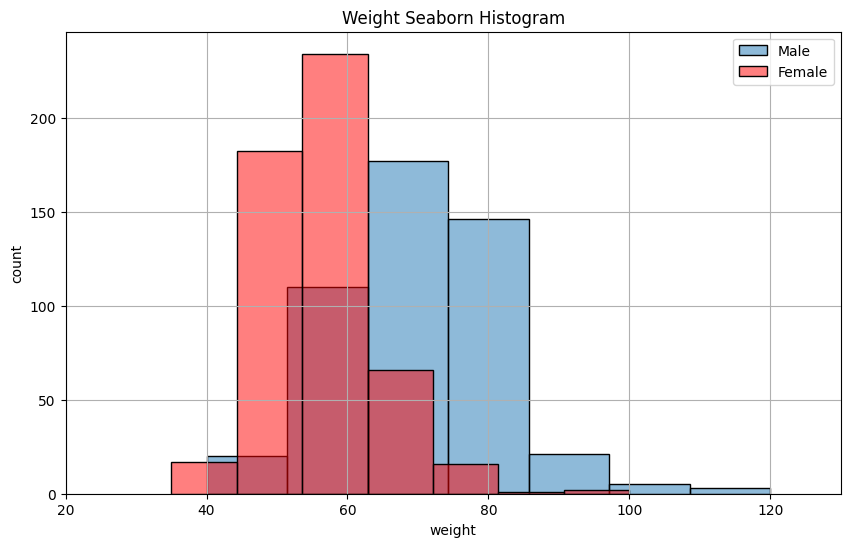

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(male_data['weight'], bins=7, alpha=0.5, label='Male')
sns.histplot(female_data['weight'], bins=7, alpha=0.5, label='Female', color='r')

plt.xlim(20,130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('Weight Seaborn Histogram')
plt.legend()
plt.grid()
plt.show()

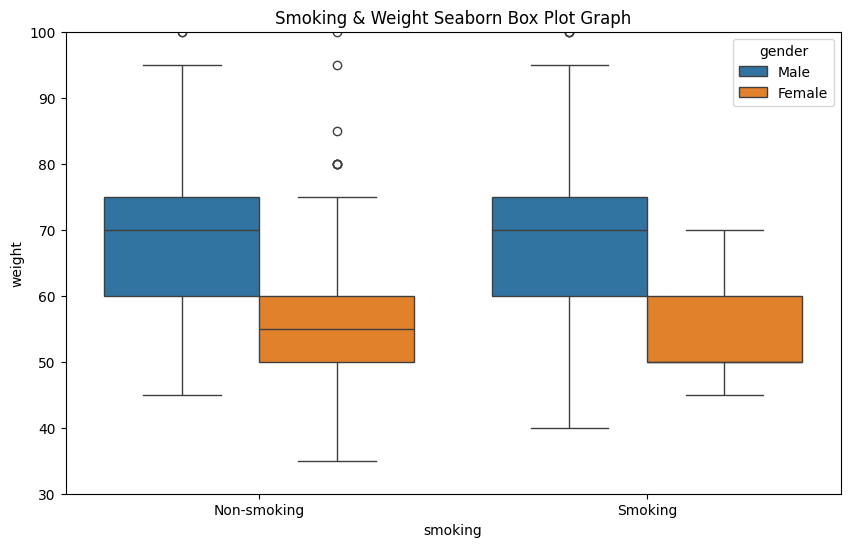

In [22]:
plt.figure(figsize=(10,6))
plt.title('Smoking & Weight Seaborn Box Plot Graph')

sns.boxplot(data=data6, x='smoking', y='weight', hue='gender')

plt.ylim(30,100)
plt.show()

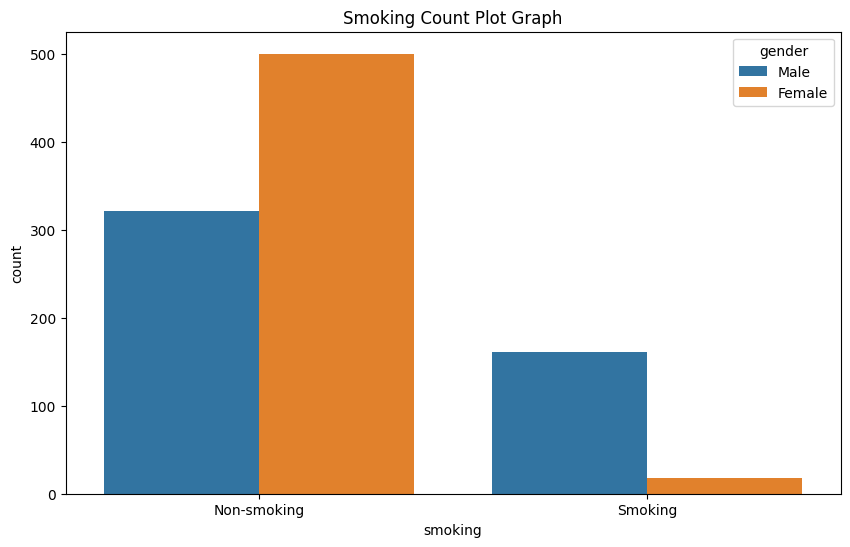

In [23]:
plt.figure(figsize=(10,6))
plt.title('Smoking Count Plot Graph')

sns.countplot(data=data6, x='smoking', hue='gender')

plt.show()

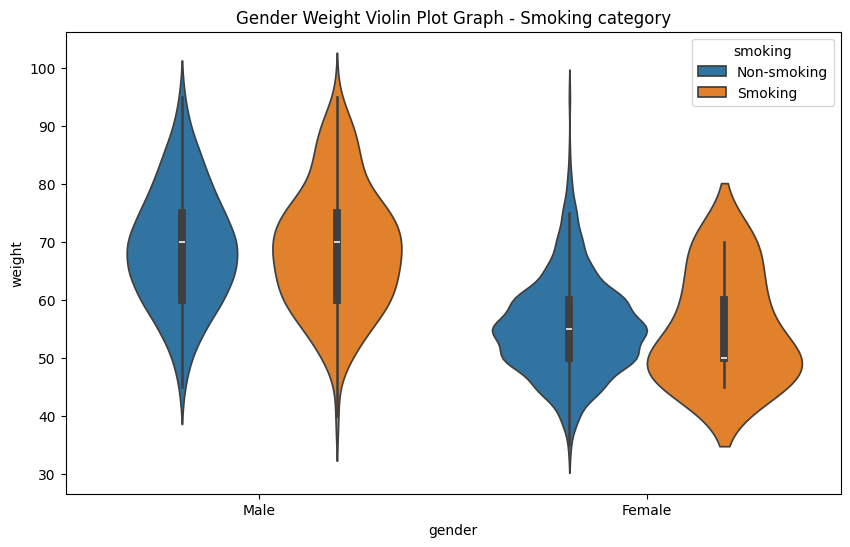

In [24]:
plt.figure(figsize=(10,6))
plt.title('Gender Weight Violin Plot Graph - Smoking category')

sns.violinplot(data=data6[data6.weight<100], x='gender', y='weight', hue='smoking')

plt.show()

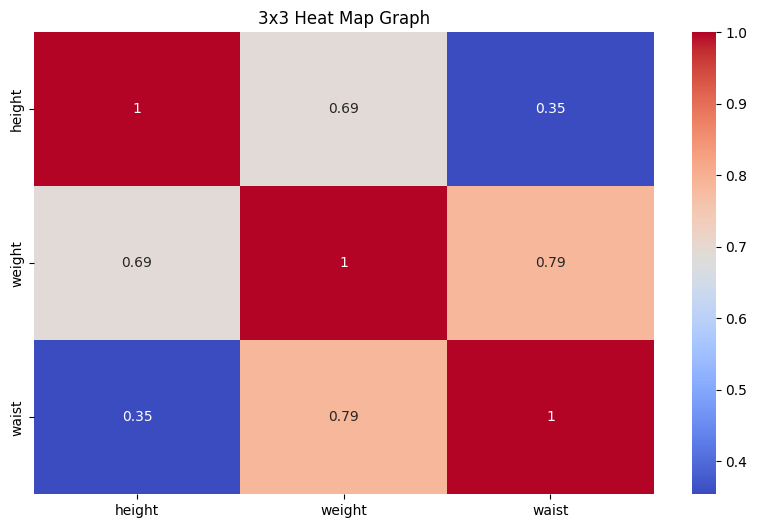

In [25]:
data3 = data.loc[:, ['height', 'weight', 'waist']]

plt.figure(figsize=(10,6))
plt.title('3x3 Heat Map Graph')

correlation_data3 = data3.corr()
sns.heatmap(correlation_data3, annot=True, cmap='coolwarm')

plt.show()